In [8]:
import os
import pandas as pd
import numpy as np
from scipy.stats import randint
import seaborn as sns # used for plot interactive graph.
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,precision_score, recall_score, f1_score
from sklearn import metrics

In [3]:

# loading data
df = pd.read_csv('datasets/complaints.csv', low_memory=False)
# print(df.shape)
# print(df.head(3).T)
# Create a new dataframe with two columns
df1 = df[['Product', 'Consumer complaint narrative']].copy()
# Remove missing values (NaN)
df1 = df1[pd.notnull(df1['Consumer complaint narrative'])]
# Renaming second column for a simpler name
# print(df.columns)
df1.columns = ['Product', 'Consumer_complaint']
# print(df1.shape)
# print(df1.head(3).T)
df1_values = pd.DataFrame(df1.Product.unique()).values
print(df1_values)


[['Credit reporting or other personal consumer reports']
 ['Debt collection']
 ['Credit card']
 ['Money transfer, virtual currency, or money service']
 ['Mortgage']
 ['Checking or savings account']
 ['Payday loan, title loan, personal loan, or advance loan']
 ['Vehicle loan or lease']
 ['Student loan']
 ['Prepaid card']
 ['Debt or credit management']
 ['Credit reporting, credit repair services, or other personal consumer reports']
 ['Bank account or service']
 ['Consumer Loan']
 ['Credit reporting']
 ['Credit card or prepaid card']
 ['Payday loan']
 ['Money transfers']
 ['Payday loan, title loan, or personal loan']
 ['Other financial service']
 ['Virtual currency']]


In [4]:
# Because the computation is time consuming (in terms of CPU), the data was sampled
df2 = df1.sample(10000, random_state=1).copy()
# Renaming categories
df2.replace({'Product':
                 {
                 'Credit reporting or other personal consumer reports':'Credit reporting',
                 'Credit reporting, credit repair services, or other personal consumer reports':'Credit reporting',
                  'Credit card': 'Credit card or prepaid card',
                  'Prepaid card': 'Credit card or prepaid card',
                  'Debt or credit management': 'Debt collection,credit management',
                  'Payday loan': 'Payday loan, title loan, or personal loan',
                  'Bank account': 'Bank account,checking and saving account or service',
                  'Money transfer': 'Money transfer, virtual currency, or money service',
                  'Consumer loan': 'Consumer loan',
                  'Student loan': 'Consumer loan',
                  'Mortgage': 'Consumer loan',
                  'Vehicle loan': 'Consumer loan',
                  'Other financial service': 'Other financial service',
                  'Virtual currency': 'Money transfer, virtual currency, or money service'
                  }

             },
            inplace=True)
df2_reduced_values = pd.DataFrame(df2.Product.unique())
# Create a new column 'category_id' with encoded categories
df2['category_id'] = df2['Product'].factorize()[0]
category_id_df = df2[['Product', 'category_id']].drop_duplicates()
# Dictionaries for future use
category_to_id = dict(category_id_df.values)
id_to_category = dict(category_id_df[['category_id', 'Product']].values)
# New dataframe
df2_new_head = df2.head()
# print(df2_new_head)
# print(id_to_category)


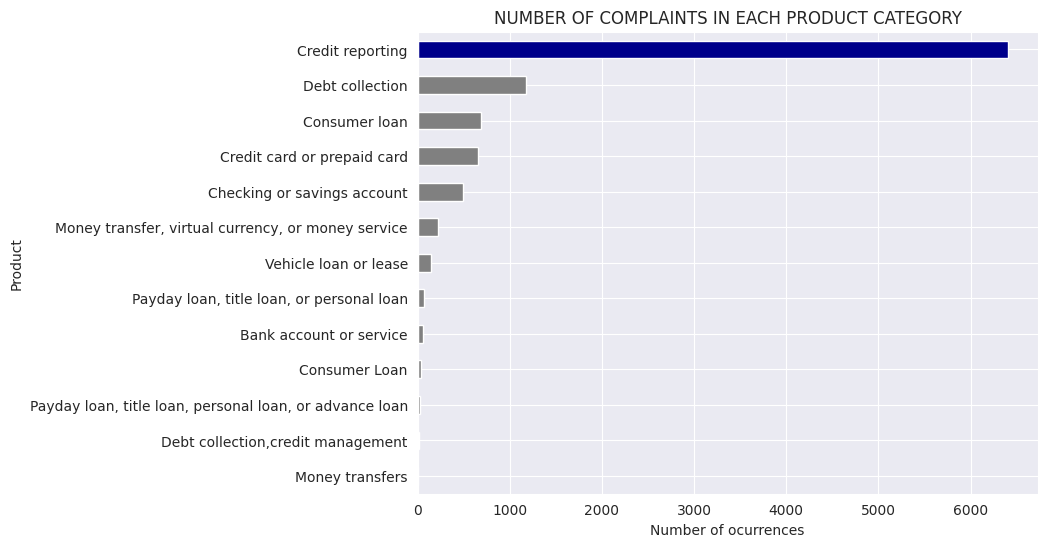

In [5]:
fig = plt.figure(figsize=(8, 6))
colors = ['grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey', 'grey',
          'darkblue', 'darkblue', 'darkblue','darkblue']
df2.groupby('Product').Consumer_complaint.count().sort_values().plot.barh(
    ylim=0, color=colors, title='NUMBER OF COMPLAINTS IN EACH PRODUCT CATEGORY')
plt.xlabel('Number of ocurrences', fontsize=10)
plt.show()

In [6]:

# Transform texts into vectors using TFIDF and evaluate how important a particular word is in the collection of words.
# Word importance is determined in terms of frequency. min_df:remove word occurred less than specified value
tfidf = TfidfVectorizer(sublinear_tf=True, min_df=5,
                        ngram_range=(1, 2),
                        stop_words='english')
# We transform each complaint into a vector
features = tfidf.fit_transform(df2.Consumer_complaint).toarray()
labels = df2.category_id
print("Each of the %d complaints is represented by %d features (TF-IDF score of unigrams and bigrams)" % (
    features.shape))

Each of the 10000 complaints is represented by 25502 features (TF-IDF score of unigrams and bigrams)


In [7]:
# Finding the three most correlated terms with each of the product categories
N = 3
for Product, category_id in sorted(category_to_id.items()):
    features_chi2 = chi2(features, labels == category_id)
    indices = np.argsort(features_chi2[0])
    feature_names = np.array(tfidf.get_feature_names_out())[indices]
    unigrams = [v for v in feature_names if len(v.split(' ')) == 1]
    bigrams = [v for v in feature_names if len(v.split(' ')) == 2]
    print("n==> %s:" % (Product))
    print("  * Most Correlated Unigrams are: %s" % (', '.join(unigrams[-N:])))
    print("  * Most Correlated Bigrams are: %s" % (', '.join(bigrams[-N:])))

n==> Bank account or service:
  * Most Correlated Unigrams are: maker, atm, bonus
  * Most Correlated Bigrams are: account td, checking account, opened checking
n==> Checking or savings account:
  * Most Correlated Unigrams are: bank, funds, overdraft
  * Most Correlated Bigrams are: navy federal, checking account, overdraft fees
n==> Consumer Loan:
  * Most Correlated Unigrams are: desperate, vehicle, truck
  * Most Correlated Bigrams are: 12 month, truck xxxx, worst customer
n==> Consumer loan:
  * Most Correlated Unigrams are: escrow, loan, mortgage
  * Most Correlated Bigrams are: escrow account, mortgage company, loan modification
n==> Credit card or prepaid card:
  * Most Correlated Unigrams are: amex, rewards, card
  * Most Correlated Bigrams are: card company, american express, credit card
n==> Credit reporting:
  * Most Correlated Unigrams are: reporting, told, bank
  * Most Correlated Bigrams are: credit report, 1681 section, consumer reporting
n==> Debt collection:
  * Most 

In [10]:
# print(df1['Product'].unique())
print(len(df1['Product']))
# print(len(df2['Product'].unique()))
# print(df2['Product'].unique())

2605480


In [9]:
X = df2['Consumer_complaint'] # Collection of documents
y = df2['Product'] # Target or the labels we want to predict (i.e., the 15 different complaints of products)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                   random_state = 0)

In [14]:
fitted_vectorizer = tfidf.fit(X_train)
tfidf_vectorizer_X_vectors = fitted_vectorizer.transform(X_train)
tfidf_X_test = tfidf.transform(X_test)
model = LinearSVC().fit(tfidf_vectorizer_X_vectors, y_train)
y_pred = model.predict(tfidf_X_test)
labels1 = sorted(df2['category_id'].unique())

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted',zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1-Score:", f1_score(y_test, y_pred, average='weighted'))
# print(classification_report(y_test, y_pred))

Accuracy: 0.8452
Precision: 0.8266321876354393
Recall: 0.8452
F1-Score: 0.8339226849819495


In [20]:
# Test model prediction
complaint = """I hope you are doing well.

I am writing to request the renewal of my payment card, as I rely on it for online purchases. My current card is set to expire soon, and I would like to ensure there is no interruption in my ability to make purchases.

Could you kindly assist me in processing the renewal of my card? If there are any steps I need to take on my end or any required information you need from me, please let me know.

Thank you for your prompt attention to this matter. I look forward to your response"""
print(model.predict(fitted_vectorizer.transform([complaint])))
print(df2_new_head['Product'].unique())

['Credit reporting']
['Vehicle loan or lease' 'Credit reporting' 'Credit card or prepaid card']


In [15]:
# Validate different models
models = [
    RandomForestClassifier(n_estimators=100, max_depth=5, random_state=0),
    LinearSVC(),
    MultinomialNB(),
    LogisticRegression(random_state=0),
]
# 5 Cross-validation
CV = 5
cv_df = pd.DataFrame(index=range(CV * len(models)))
entries = []
for model in models:
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, features, labels, scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])

/home/legion/Documents/Legion/Development/pydjango/ai-practice/venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/legion/Documents/Legion/Development/pydjango/ai-practice/venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/legion/Documents/Legion/Development/pydjango/ai-practice/venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/home/legion/Documents/Legion/Development/pydjango/ai-practice/venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


In [48]:
mean_accuracy = cv_df.groupby('model_name').accuracy.mean()
std_accuracy = cv_df.groupby('model_name').accuracy.std()

acc = pd.concat([mean_accuracy, std_accuracy], axis= 1,
          ignore_index=True)
acc.columns = ['Mean Accuracy', 'Standard deviation']
acc

,Mean Accuracy,Standard deviation
model_name,,
LinearSVC,0.8453,0.004957
LogisticRegression,0.8343,0.003947
MultinomialNB,0.7555,0.003317
RandomForestClassifier,0.6407,0.000447
